# Pipeline de Analisis Estadistico No Supervisado y Feature Selection
# Base de Proyectos SGR

## Descripcion General

Este notebook implementa un pipeline de analisis exploratorio y seleccion de variables
sobre la base de datos de proyectos del Sistema General de Regalias (SGR), sin depender
de una variable objetivo (enfoque no supervisado).

El flujo comprende las siguientes etapas:

1. Ingesta y estandarizacion de un archivo Excel con estructura irregular (headers multinivel).
2. Limpieza y preprocesamiento: eliminacion de columnas con exceso de nulos, imputacion
   estadistica y filtro de varianza cercana a cero.
3. Analisis de correlacion y deteccion de multicolinealidad mediante VIF.
4. Analisis exploratorio no supervisado: PCA (solo exploratorio, no para seleccion),
   clustering jerarquico y K-Means con analisis de silueta.
5. Seleccion no supervisada de variables relevantes mediante tres metodos complementarios:
   Laplacian Score, varianza normalizada y analisis de loadings PCA, consolidados en un
   ranking cruzado interpretable sobre las variables originales.


## Fase 0 : Instalacion de Dependencias

Ejecutar esta celda unicamente si alguna de las librerias no esta instalada en el entorno.


In [ ]:
# Descomentar segun sea necesario
!pip install pandas openpyxl scikit-learn matplotlib seaborn statsmodels scipy

## Fase 0.1 : Importacion de Librerias


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import kneighbors_graph
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from scipy.sparse.csgraph import laplacian as csgraph_laplacian

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 11

print("Todas las librerias cargadas correctamente.")


Todas las librerias cargadas correctamente.


## Fase 0.2 : Variables Globales de Configuracion

Estos parametros controlan el comportamiento del pipeline. Modificarlos segun las
necesidades del analisis antes de ejecutar las celdas posteriores.


In [24]:
# =====================================================================
# VARIABLES GLOBALES - MODIFICAR SEGUN NECESIDAD
# =====================================================================

# Ruta al archivo Excel
RUTA_EXCEL = r"..\..\data\raw\Base de proyectos _15_12_2025.xlsx"

# Nombre de la hoja a procesar
HOJA = "PROYECTOS APROBADOS "

# Filas de encabezado (0-indexed). Fila 1 y 2 de Excel = indices 0 y 1
# Ajustar si el archivo tiene filas vacias encima de los headers.
# Para el archivo original "Base de proyectos_15_12_2025.xlsx" con hoja
# "PROYECTOS APROBADOS" donde los headers empiezan en la fila 6:
#   HEADER_ROWS = [5, 6]
HEADER_ROWS = [5, 6]

# Umbral de nulidad: columnas con % de nulos superior a este valor se eliminan
UMBRAL_NULOS = 0.60

# Umbral de varianza cercana a cero (en escala normalizada)
UMBRAL_VARIANZA = 0.01

# Umbral de VIF para considerar multicolinealidad severa
UMBRAL_VIF = 10

# Numero de variables top a reportar en el resumen final
TOP_N = 15

# Numero de vecinos para el calculo de Laplacian Score
N_VECINOS_LAPLACIAN = 5

# Numero maximo de clusters a evaluar en K-Means
MAX_K_CLUSTERS = 10

# Semilla de reproducibilidad
RANDOM_STATE = 42

# Cardinalidad maxima para codificar categoricas (Label Encoding)
MAX_CARDINALIDAD = 50

print("Variables globales configuradas.")


Variables globales configuradas.


# Fase 1 : Ingesta y Estandarizacion

## Estrategia de Lectura

El archivo Excel presenta una estructura irregular con dos filas de encabezado.
La primera fila contiene headers de grupo (ej. CARACTERIZACION DEL PROYECTO,
APROBACION DEL PROYECTO, EJECUCION DEL PROYECTO, FUENTES DE FINANCIACION) y
la segunda fila contiene los nombres individuales de cada columna (ej. BPIN,
VALOR SGP, VALOR SGR).

La funcion de ingesta lee ambas filas como MultiIndex y luego aplana los nombres
de columna concatenando el nivel de grupo con el nombre individual. Los niveles
"Unnamed" generados por celdas fusionadas se omiten automaticamente.


In [25]:
def ingestar_excel(ruta, hoja, header_rows, skiprows=None, usecols=None):
    """
    Lee un archivo Excel con estructura irregular y aplana headers multinivel.

    Parametros
    ----------
    ruta : str
        Ruta al archivo .xlsx.
    hoja : str
        Nombre de la hoja a leer.
    header_rows : list[int]
        Indices (0-based) de las filas que contienen los encabezados.
    skiprows : list[int] o None
        Filas adicionales a omitir durante la lectura.
    usecols : str, list o None
        Columnas especificas a leer (ej. "A:Z" o [0,1,2]).

    Retorna
    -------
    pd.DataFrame
        DataFrame con columnas aplanadas y tipos inferidos.
    """
    df = pd.read_excel(
        ruta,
        sheet_name=hoja,
        header=header_rows,
        skiprows=skiprows,
        usecols=usecols,
        engine="openpyxl"
    )

    # --- Aplanamiento de MultiIndex en columnas ---
    if isinstance(df.columns, pd.MultiIndex):
        nuevas_columnas = []
        for niveles in df.columns:
            partes = []
            for parte in niveles:
                s = str(parte).strip()
                if "Unnamed" not in s:
                    partes.append(s)
            nombre = "_".join(partes) if partes else "SIN_NOMBRE"
            nuevas_columnas.append(nombre)
        df.columns = nuevas_columnas
    else:
        df.columns = [str(c).strip() for c in df.columns]

    # Eliminar columnas y filas completamente vacias
    df = df.dropna(axis=1, how="all")
    df = df.dropna(axis=0, how="all")
    df = df.reset_index(drop=True)

    return df


# --- Ejecutar ingesta ---
df_raw = ingestar_excel(
    ruta=RUTA_EXCEL,
    hoja=HOJA,
    header_rows=HEADER_ROWS
)

print(f"Dimensiones del DataFrame crudo: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas")
print(f"\nPrimeras 5 columnas:")
for c in df_raw.columns[:5]:
    print(f"  - {c}")
print(f"\nUltimas 5 columnas:")
for c in df_raw.columns[-5:]:
    print(f"  - {c}")
df_raw.head(3)


Dimensiones del DataFrame crudo: 35388 filas x 152 columnas

Primeras 5 columnas:
  - CARACTERIZACIÓN DEL PROYECTO_BPIN
  - CARACTERIZACIÓN DEL PROYECTO_NOMBRE DEL PROYECTO
  - CARACTERIZACIÓN DEL PROYECTO_SECTOR
  - CARACTERIZACIÓN DEL PROYECTO_PROGRAMA
  - CARACTERIZACIÓN DEL PROYECTO_SUBPROGRAMA

Ultimas 5 columnas:
  - FUENTES DE FINANCIACIÓN DETALLADAS_SGR - ASIGNACIÓN PARA LA INVERSIÓN REGIONAL PROYECTOS INFRAES TRANPORTE ACUERDO PAZ (126)
  - FUENTES DE FINANCIACIÓN DETALLADAS_SGR - ASIGNACIÓN PARA LA INVERSIÓN REGIONAL 60% GESTIÓN DEL REISGO Y ADAPTACIÓN AL CAMBIO CLIMÁTICO LEY 2056 (128)
  - FUENTES DE FINANCIACIÓN DETALLADAS_ASIGNACIONES DIRECTAS - GESTIÓN DEL RIESGO, ADAPTACIÓN AL CAMBIO CLIMÁTICO O SITUACIONES DE EMERGENCIA (166)
  - FUENTES DE FINANCIACIÓN DETALLADAS_SGR - 20% DE MAYOR RECAUDO DESTINADO A LA CONSERVACIÓN DE LAS ÁREAS AMBIENTALES ESTRATÉGICAS Y LA LUCHA NACIONAL CONTRA LA DEFORESTACIÓN (129)
  - FUENTES DE FINANCIACIÓN DETALLADAS_SGR - ASIGNACIÓN PARA LA IN

,CARACTERIZACIÓN DEL PROYECTO_BPIN,CARACTERIZACIÓN DEL PROYECTO_NOMBRE DEL PROYECTO,CARACTERIZACIÓN DEL PROYECTO_SECTOR,CARACTERIZACIÓN DEL PROYECTO_PROGRAMA,CARACTERIZACIÓN DEL PROYECTO_SUBPROGRAMA,CARACTERIZACIÓN DEL PROYECTO_ALCANCE,CARACTERIZACIÓN DEL PROYECTO_FASE DEL PROYECTO,CARACTERIZACIÓN DEL PROYECTO_DESTINO DE RECURSOS \n(Según la fase del proyecto),CARACTERIZACIÓN DEL PROYECTO_ESTADO GENERAL,CARACTERIZACIÓN DEL PROYECTO_FECHA ESTADO GENERAL PROYECTO,...,"FUENTES DE FINANCIACIÓN DETALLADAS_SGR - ASIGNACIÓN PARA LA INVERSIÓN EN CIENCIA, TECNOLOGÍA E INNOVACIÓN LEY 2056 (114)","FUENTES DE FINANCIACIÓN DETALLADAS_SGR - ASIGNACIÓN PARA LA INVERSIÓN EN CIENCIA, TECNOLOGÍA E INNOVACIÓN CONVOCATORIAS 2021 -AMBIENTE Y DESARROLLO LEY 2056 (115)",FUENTES DE FINANCIACIÓN DETALLADAS_SGR - ASIGNACIÓN PARA LA PAZ LEY 2056 (116),FUENTES DE FINANCIACIÓN DETALLADAS_SGR - ASIGNACIÓN ADELANTO PAZ LEY 2056 (119),FUENTES DE FINANCIACIÓN DETALLADAS_SGR ASIGNACIÓN PARA LA PAZ - PROYECTOS DE INFRAESTRUCTURA DE TRANSPORTE PARA LA IMPLEMENTACIÓN DEL ACUERDO DE PAZ LEY 2056 (124),FUENTES DE FINANCIACIÓN DETALLADAS_SGR - ASIGNACIÓN PARA LA INVERSIÓN REGIONAL PROYECTOS INFRAES TRANPORTE ACUERDO PAZ (126),FUENTES DE FINANCIACIÓN DETALLADAS_SGR - ASIGNACIÓN PARA LA INVERSIÓN REGIONAL 60% GESTIÓN DEL REISGO Y ADAPTACIÓN AL CAMBIO CLIMÁTICO LEY 2056 (128),"FUENTES DE FINANCIACIÓN DETALLADAS_ASIGNACIONES DIRECTAS - GESTIÓN DEL RIESGO, ADAPTACIÓN AL CAMBIO CLIMÁTICO O SITUACIONES DE EMERGENCIA (166)",FUENTES DE FINANCIACIÓN DETALLADAS_SGR - 20% DE MAYOR RECAUDO DESTINADO A LA CONSERVACIÓN DE LAS ÁREAS AMBIENTALES ESTRATÉGICAS Y LA LUCHA NACIONAL CONTRA LA DEFORESTACIÓN (129),FUENTES DE FINANCIACIÓN DETALLADAS_SGR - ASIGNACIÓN PARA LA INVERSIÓN REGIONAL - REACTIVACIÓN ECONÓMICA (210)
0,2022006910133,FORTALECIMIENTO DE LA CAPACIDAD OPERATIVA PARA...,GOBIERNO TERRITORIAL,FORTALECIMIENTO A LA GESTIÓN Y DIRECCIÓN DE LA...,INTERSUBSECTORIAL GOBIERNO,DOTACIÓN Y ADECUACIÓN DE LA SEDE PRINCIPAL DE ...,FACTIBILIDAD - FASE 3,EJECUCION,TERMINADO,2025-10-15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022006910134,CONSTRUCCIÓN DE AULAS EN LA I.E. FRANCISCO ROS...,EDUCACIÓN,"CALIDAD, COBERTURA Y FORTALECIMIENTO DE LA EDU...",INTERSUBSECTORIAL EDUCACION,CONSTRUCCIÓN DE UNA SEDE EDUCATIVA EN 10 SALON...,FACTIBILIDAD - FASE 3,EJECUCION,TERMINADO,2024-07-13,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2023000060021,CONSTRUCCIÓN DEL SISTEMA DE ALUMBRADO PÚBLICO ...,MINAS Y ENERGÍA,CONSOLIDACIÓN PRODUCTIVA DEL SECTOR DE ENERGÍA...,INTERSUBSECTORIAL MINAS Y ENERGÍA,CONSTRUIR 2 SISTEMAS DE ALUMBRADO PUBLICO CON ...,FACTIBILIDAD - FASE 3,EJECUCION,EN EJECUCIÓN,2024-06-17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Fase 1.1 : Inspeccion Inicial del DataFrame

Revision de tipos de datos, conteo de nulos por columna, distribucion de grupos
tematicos (segun el prefijo del header de grupo) y estadisticas descriptivas
para comprender la calidad de los datos antes de la limpieza.


In [26]:
# Resumen de tipos y nulos
print("=" * 70)
print("RESUMEN DE TIPOS DE DATOS Y NULIDAD")
print("=" * 70)

resumen = pd.DataFrame({
    "tipo": df_raw.dtypes.astype(str),
    "no_nulos": df_raw.count(),
    "nulos": df_raw.isnull().sum(),
    "pct_nulos": (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    "unicos": df_raw.nunique()
})
resumen = resumen.sort_values("pct_nulos", ascending=False)

# Mostrar solo las que tienen nulos
con_nulos = resumen[resumen["nulos"] > 0]
print(f"\nColumnas con algun valor nulo ({len(con_nulos)} de {len(resumen)}):")
print(con_nulos.to_string())

print(f"\n{'=' * 70}")
print(f"Total columnas: {df_raw.shape[1]}")
print(f"Total filas: {df_raw.shape[0]}")
print(f"Columnas con >{UMBRAL_NULOS*100:.0f}% nulos: {(resumen['pct_nulos'] > UMBRAL_NULOS * 100).sum()}")
print(f"Columnas sin ningun nulo: {(resumen['nulos'] == 0).sum()}")


RESUMEN DE TIPOS DE DATOS Y NULIDAD

Columnas con algun valor nulo (55 de 152):
                                                                                                                         tipo  no_nulos  nulos  pct_nulos  unicos
CONTROL SOCIAL DEL PROYECTO_ÚLTIMA FECHA DEL APORTE CIUDADANO A PROYECTO SGR_APP_AC                            datetime64[us]       104  35284      99.71      89
CONTROL SOCIAL DEL PROYECTO_PROYECTO SGR CON APORTE CIUDADANO_APP_AC                                                      str       104  35284      99.71       3
EJECUCIÓN DEL PROYECTO_OBSERVACIONES AL AVANCE FÍSICO Y FINANCIERO                                                        str       216  35172      99.39       2
EJECUCIÓN DEL PROYECTO_OBSERVACIÓN PAGOS                                                                                  str       226  35162      99.36       1
APROBACIÓN DEL PROYECTO_LIBERACIÓN DE RECURSOS                                                                

In [27]:
# Distribucion de tipos de datos
print("Distribucion de tipos de datos:")
print(df_raw.dtypes.astype(str).value_counts())

# Distribucion por grupo tematico (prefijo antes del primer '_')
grupos = [c.split("_")[0] if "_" in c else "SIN_GRUPO" for c in df_raw.columns]
print(f"\nDistribucion por grupo tematico:")
for g, n in pd.Series(grupos).value_counts().items():
    print(f"  {g}: {n} columnas")


Distribucion de tipos de datos:
float64           79
str               47
datetime64[us]    18
int64              7
object             1
Name: count, dtype: int64

Distribucion por grupo tematico:
  FUENTES DE FINANCIACIÓN DETALLADAS: 42 columnas
  CARACTERIZACIÓN DEL PROYECTO: 41 columnas
  EJECUCIÓN DEL PROYECTO: 31 columnas
  ENTIDAD EJECUTORA DEL PROYECTO: 11 columnas
  APROBACIÓN DEL PROYECTO: 10 columnas
  FUENTES DE FINANCIACIÓN CONSOLIDADAS: 8 columnas
  CONTROL SOCIAL DEL PROYECTO: 7 columnas
  OTRAS VARIABLES DEL PROYECTO: 2 columnas


# Fase 2 : Limpieza y Preprocesamiento

## Fase 2.1 : Eliminacion de Columnas por Umbral de Nulidad

Se descartan automaticamente las columnas cuyo porcentaje de valores nulos supere
el umbral definido en UMBRAL_NULOS (por defecto, 40%). Imputar columnas con mas del
40% de datos faltantes introduce un sesgo significativo y distorsiona cualquier
estructura latente en un analisis no supervisado.


In [28]:
def eliminar_columnas_por_nulidad(df, umbral):
    """
    Elimina columnas cuyo porcentaje de valores nulos supere el umbral.

    Retorna
    -------
    pd.DataFrame, list
        DataFrame filtrado y lista de columnas eliminadas.
    """
    pct_nulos = df.isnull().mean()
    cols_eliminar = pct_nulos[pct_nulos > umbral].index.tolist()

    print(f"Columnas eliminadas por superar {umbral*100:.0f}% de nulos: {len(cols_eliminar)}")
    if len(cols_eliminar) <= 20:
        for col in cols_eliminar:
            print(f"  - {col}: {pct_nulos[col]*100:.1f}% nulos")
    else:
        for col in cols_eliminar[:10]:
            print(f"  - {col}: {pct_nulos[col]*100:.1f}% nulos")
        print(f"  ... y {len(cols_eliminar) - 10} columnas mas.")

    df_limpio = df.drop(columns=cols_eliminar)
    return df_limpio, cols_eliminar


df_filtrado, cols_eliminadas_nulos = eliminar_columnas_por_nulidad(df_raw, UMBRAL_NULOS)
print(f"\nDimensiones tras filtro de nulidad: {df_filtrado.shape}")


Columnas eliminadas por superar 60% de nulos: 32
  - CARACTERIZACIÓN DEL PROYECTO_PROGRAMAS DE DESARROLLO CON ENFOQUE TERRITORIAL - PDET (SEGÚN ENTIDAD EJECUTORA): 90.0% nulos
  - CARACTERIZACIÓN DEL PROYECTO_SUBREGIONES PDET PROYECTOS APROBADOS OCAD PAZ (SEGÚN LOCALIZACIÓN): 97.5% nulos
  - CARACTERIZACIÓN DEL PROYECTO_CONSOLIDADO PDET: 88.9% nulos
  - CARACTERIZACIÓN DEL PROYECTO_VALOR TOTAL INICIAL: 89.6% nulos
  - CARACTERIZACIÓN DEL PROYECTO_VALOR SGR APROBADO INICIAL: 89.6% nulos
  - CARACTERIZACIÓN DEL PROYECTO_TIENE AJUSTES POR MONTO SGR: 89.6% nulos
  - CARACTERIZACIÓN DEL PROYECTO_CUANTOS AJUSTES PRESENTA POR VALOR SGR: 89.6% nulos
  - CARACTERIZACIÓN DEL PROYECTO_VALOR TOTAL DE LOS AJUSTES SGR: 89.6% nulos
  - CARACTERIZACIÓN DEL PROYECTO_ÚLTIMA FECHA DE AJUSTE: 89.6% nulos
  - CARACTERIZACIÓN DEL PROYECTO_TRANSFORMACIONES PLAN NACIONAL DE DESARROLLO: 70.3% nulos
  ... y 22 columnas mas.

Dimensiones tras filtro de nulidad: (35388, 120)


## Fase 2.2 : Imputacion de Valores Faltantes Residuales

Para columnas numericas con nulos residuales se aplica imputacion por mediana
(robusta frente a valores atipicos, frecuentes en datos presupuestales).
Para columnas categoricas, se imputa con la moda o con "SIN_DATO".


In [29]:
def imputar_nulos(df):
    """
    Imputa valores nulos:
    - Numericas: mediana.
    - Categoricas: moda o 'SIN_DATO'.

    Retorna
    -------
    pd.DataFrame, dict
        DataFrame imputado y registro de imputaciones.
    """
    registro = {}
    df_imp = df.copy()

    # Numericas
    cols_num = df_imp.select_dtypes(include=[np.number]).columns
    for col in cols_num:
        n_nulos = df_imp[col].isnull().sum()
        if n_nulos > 0:
            mediana = df_imp[col].median()
            df_imp[col] = df_imp[col].fillna(mediana)
            registro[col] = {"metodo": "mediana", "valor": mediana, "n": n_nulos}

    # Categoricas
    cols_cat = df_imp.select_dtypes(include=["object", "string", "category"]).columns
    for col in cols_cat:
        n_nulos = df_imp[col].isnull().sum()
        if n_nulos > 0:
            moda = df_imp[col].mode()
            valor_imp = moda.iloc[0] if len(moda) > 0 else "SIN_DATO"
            df_imp[col] = df_imp[col].fillna(valor_imp)
            registro[col] = {"metodo": "moda", "valor": valor_imp, "n": n_nulos}

    # Fechas: imputar con la mediana de la columna datetime
    cols_dt = df_imp.select_dtypes(include=["datetime64"]).columns
    for col in cols_dt:
        n_nulos = df_imp[col].isnull().sum()
        if n_nulos > 0:
            mediana_dt = df_imp[col].dropna().median()
            df_imp[col] = df_imp[col].fillna(mediana_dt)
            registro[col] = {"metodo": "mediana_fecha", "valor": str(mediana_dt), "n": n_nulos}

    print(f"Variables imputadas: {len(registro)}")
    for k, v in list(registro.items())[:10]:
        print(f"  {k}: {v['metodo']} = {v['valor']} ({v['n']} nulos)")
    if len(registro) > 10:
        print(f"  ... y {len(registro) - 10} mas.")

    return df_imp, registro


df_imputado, registro_imputacion = imputar_nulos(df_filtrado)
assert df_imputado.isnull().sum().sum() == 0, "ERROR: Quedan valores nulos."
print(f"\nVerificacion: 0 nulos restantes. OK.")
print(f"Dimensiones: {df_imputado.shape}")


Variables imputadas: 23
  ENTIDAD EJECUTORA DEL PROYECTO_DIGITO VERIFICACIÓN: mediana = 4.0 (216 nulos)
  ENTIDAD EJECUTORA DEL PROYECTO_CAPACIDAD INSTITUCIONAL: mediana = 3.0 (217 nulos)
  EJECUCIÓN DEL PROYECTO_NUMERO DE CONTRATOS ASOCIADOS AL PROYECTO: mediana = 2.0 (1356 nulos)
  EJECUCIÓN DEL PROYECTO_NUMERO DE CONTRATOS SUSPENDIDOS: mediana = 0.0 (1356 nulos)
  EJECUCIÓN DEL PROYECTO_NUMERO DE CONTRATOS VIGENTES: mediana = 2.0 (1356 nulos)
  EJECUCIÓN DEL PROYECTO_PLAZO(MESES) PROGRAMACIÓN: mediana = 7.0 (1319 nulos)
  CARACTERIZACIÓN DEL PROYECTO_ALCANCE: moda = NO APLICA (10672 nulos)
  CARACTERIZACIÓN DEL PROYECTO_FASE DEL PROYECTO: moda = FACTIBILIDAD - FASE 3 (11 nulos)
  CARACTERIZACIÓN DEL PROYECTO_DESTINO DE RECURSOS 
(Según la fase del proyecto): moda = EJECUCION (11 nulos)
  ENTIDAD EJECUTORA DEL PROYECTO_REGION EJECUTOR: moda = CARIBE (216 nulos)
  ... y 13 mas.

Verificacion: 0 nulos restantes. OK.
Dimensiones: (35388, 120)


## Fase 2.3 : Eliminacion de Variables con Varianza Cercana a Cero

Las variables constantes o cuasi-constantes no aportan informacion discriminante.
En este dataset, muchas columnas de fuentes de financiacion detalladas contienen
ceros en casi todas las filas. Se normalizan las columnas al rango [0, 1] y se
eliminan aquellas cuya varianza normalizada sea inferior a UMBRAL_VARIANZA.
Las categoricas con un unico valor tambien se eliminan.


In [30]:
def eliminar_baja_varianza(df, umbral_var):
    """
    Elimina columnas numericas con varianza normalizada < umbral
    y categoricas con un unico valor.

    Retorna
    -------
    pd.DataFrame, list
    """
    cols_eliminar = []

    # Numericas
    cols_num = df.select_dtypes(include=[np.number]).columns
    for col in cols_num:
        rango = df[col].max() - df[col].min()
        if rango == 0:
            cols_eliminar.append(col)
        else:
            normalizado = (df[col] - df[col].min()) / rango
            if normalizado.var() < umbral_var:
                cols_eliminar.append(col)

    # Categoricas con un unico valor
    cols_cat = df.select_dtypes(include=["object", "string", "category"]).columns
    for col in cols_cat:
        if df[col].nunique() <= 1:
            cols_eliminar.append(col)

    print(f"Columnas eliminadas por baja varianza: {len(cols_eliminar)}")
    if len(cols_eliminar) <= 15:
        for col in cols_eliminar:
            print(f"  - {col}")
    else:
        for col in cols_eliminar[:10]:
            print(f"  - {col}")
        print(f"  ... y {len(cols_eliminar) - 10} mas.")

    df_out = df.drop(columns=cols_eliminar)
    return df_out, cols_eliminar


df_var, cols_eliminadas_var = eliminar_baja_varianza(df_imputado, UMBRAL_VARIANZA)
print(f"\nDimensiones tras filtro de varianza: {df_var.shape}")


Columnas eliminadas por baja varianza: 68
  - CARACTERIZACIÓN DEL PROYECTO_PGN
  - CARACTERIZACIÓN DEL PROYECTO_PROPIOS
  - CARACTERIZACIÓN DEL PROYECTO_VALOR SGP
  - CARACTERIZACIÓN DEL PROYECTO_VALOR TOTAL INCLUIDO NO SUIFP
  - CARACTERIZACIÓN DEL PROYECTO_VALOR SGR
  - CARACTERIZACIÓN DEL PROYECTO_VALOR NACIÓN
  - CARACTERIZACIÓN DEL PROYECTO_VALOR OTROS
  - CARACTERIZACIÓN DEL PROYECTO_TOTAL PROYECTO
  - CARACTERIZACIÓN DEL PROYECTO_VALOR NO SUIFP
  - ENTIDAD EJECUTORA DEL PROYECTO_NIT ENTIDAD EJECUTORA
  ... y 58 mas.

Dimensiones tras filtro de varianza: (35388, 52)


## Fase 2.4 : Codificacion de Variables Categoricas

Se aplica Label Encoding a columnas categoricas con cardinalidad moderada
(menos de MAX_CARDINALIDAD categorias unicas). Las columnas de alta cardinalidad
como nombres de proyecto, localizaciones libres o entidades ejecutoras se excluyen
del analisis numerico por no ser representables sin perdida de informacion
en un esquema ordinal.


In [12]:
def codificar_categoricas(df, max_cardinalidad=50):
    """
    Label Encoding para categoricas con cardinalidad <= max_cardinalidad.
    Excluye columnas de alta cardinalidad.

    Retorna
    -------
    pd.DataFrame, list, dict
    """
    df_cod = df.copy()
    cols_excluidas = []
    encoders = {}

    cols_cat = df_cod.select_dtypes(include=["object", "string", "category"]).columns

    for col in cols_cat:
        n_unicos = df_cod[col].nunique()
        if n_unicos > max_cardinalidad:
            cols_excluidas.append(col)
            print(f"  Excluida (cardinalidad={n_unicos}): {col}")
        else:
            le = LabelEncoder()
            df_cod[col] = le.fit_transform(df_cod[col].astype(str))
            encoders[col] = le

    # Convertir columnas datetime a valores numericos (timestamp)
    cols_dt = df_cod.select_dtypes(include=["datetime64"]).columns
    for col in cols_dt:
        df_cod[col] = df_cod[col].astype(np.int64) // 10**9  # Segundos desde epoch

    if cols_excluidas:
        df_cod = df_cod.drop(columns=cols_excluidas)

    print(f"\nVariables codificadas: {len(encoders)}")
    print(f"Variables datetime convertidas: {len(cols_dt)}")
    print(f"Variables excluidas por alta cardinalidad: {len(cols_excluidas)}")

    return df_cod, cols_excluidas, encoders


df_encoded, cols_alta_card, encoders = codificar_categoricas(df_var, MAX_CARDINALIDAD)
print(f"\nDimensiones finales para analisis: {df_encoded.shape}")
print(f"Todas las columnas son numericas: {df_encoded.select_dtypes(include=[np.number]).shape[1] == df_encoded.shape[1]}")


  Excluida (cardinalidad=35388): CARACTERIZACIÓN DEL PROYECTO_BPIN
  Excluida (cardinalidad=35352): CARACTERIZACIÓN DEL PROYECTO_NOMBRE DEL PROYECTO
  Excluida (cardinalidad=141): CARACTERIZACIÓN DEL PROYECTO_PROGRAMA
  Excluida (cardinalidad=97): CARACTERIZACIÓN DEL PROYECTO_SUBPROGRAMA
  Excluida (cardinalidad=24591): CARACTERIZACIÓN DEL PROYECTO_ALCANCE
  Excluida (cardinalidad=1086): CARACTERIZACIÓN DEL PROYECTO_ENTIDAD TERRITORIAL QUE APORTA MÁS RECURSOS
  Excluida (cardinalidad=3845): CARACTERIZACIÓN DEL PROYECTO_LOCALIZACIÓN DEL PROYECTO
  Excluida (cardinalidad=1361): APROBACIÓN DEL PROYECTO_INSTANCIA DE APROBACIÓN INICIAL
  Excluida (cardinalidad=1916): ENTIDAD EJECUTORA DEL PROYECTO_ENTIDAD EJECUTORA

Variables codificadas: 26
Variables datetime convertidas: 11
Variables excluidas por alta cardinalidad: 9

Dimensiones finales para analisis: (35388, 43)
Todas las columnas son numericas: True


## Fase 2.5 : Resumen del Preprocesamiento


In [13]:
print("=" * 70)
print("RESUMEN DEL PREPROCESAMIENTO")
print("=" * 70)
print(f"Columnas originales:              {df_raw.shape[1]}")
print(f"Eliminadas por nulidad (>{UMBRAL_NULOS*100:.0f}%):  {len(cols_eliminadas_nulos)}")
print(f"Eliminadas por baja varianza:     {len(cols_eliminadas_var)}")
print(f"Excluidas por alta cardinalidad:  {len(cols_alta_card)}")
print(f"Columnas finales para analisis:   {df_encoded.shape[1]}")
print(f"Filas:                            {df_encoded.shape[0]}")
print(f"\nNota: si el dataset tiene muy pocas filas (<30), los resultados de")
print(f"clustering y PCA deben interpretarse con cautela. El pipeline esta")
print(f"disenado para funcionar con el dataset completo (~35,000+ filas).")


RESUMEN DEL PREPROCESAMIENTO
Columnas originales:              152
Eliminadas por nulidad (>60%):  32
Eliminadas por baja varianza:     68
Excluidas por alta cardinalidad:  9
Columnas finales para analisis:   43
Filas:                            35388

Nota: si el dataset tiene muy pocas filas (<30), los resultados de
clustering y PCA deben interpretarse con cautela. El pipeline esta
disenado para funcionar con el dataset completo (~35,000+ filas).


# Fase 3 : Analisis de Correlacion y Multicolinealidad

## Fase 3.1 : Matriz de Correlacion

Se calcula la correlacion de Pearson entre todas las variables numericas. La
visualizacion se limita a las 30 variables con mayor correlacion promedio absoluta
para mantener la legibilidad. Los pares con correlacion superior a 0.85 se
reportan explicitamente como candidatos a eliminacion.


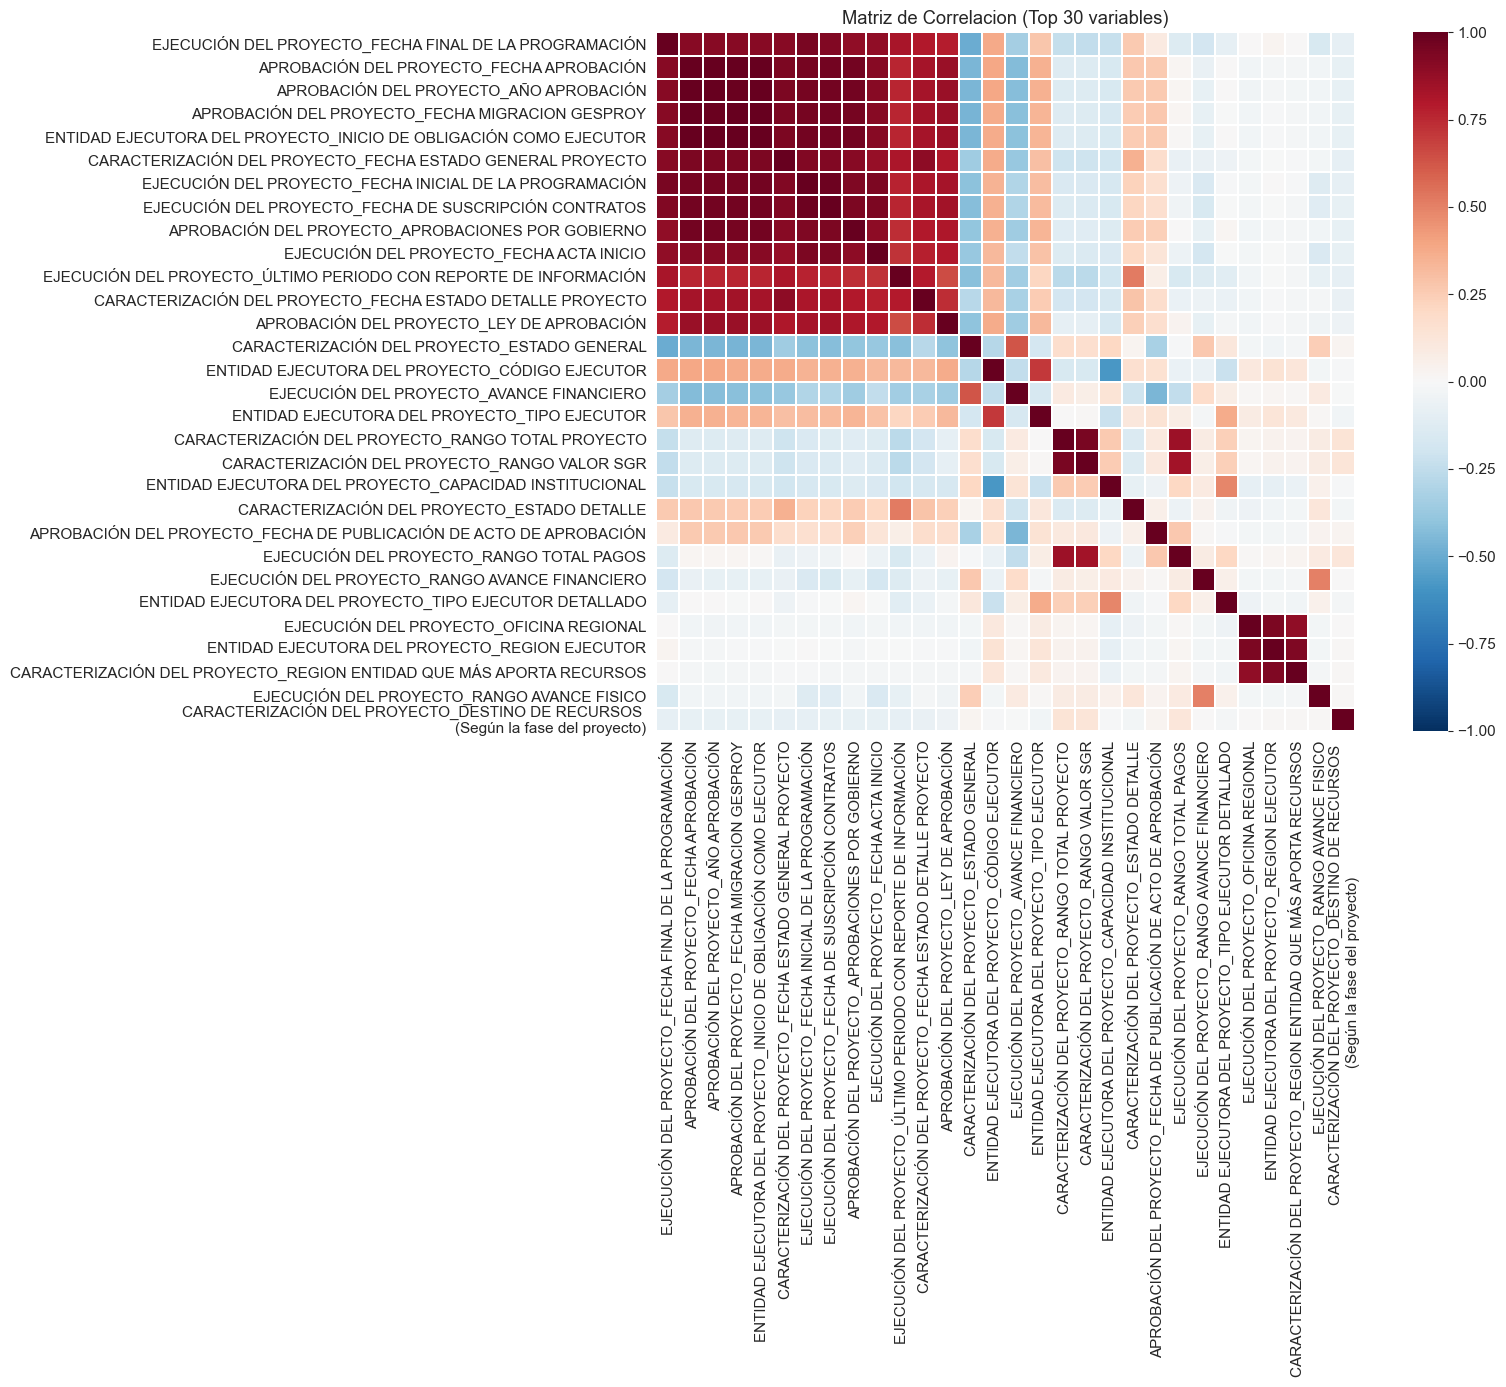


Pares de variables con |correlacion| > 0.85: 56
                                                       Variable_1                                                        Variable_2  Correlacion
                         APROBACIÓN DEL PROYECTO_FECHA APROBACIÓN                            APROBACIÓN DEL PROYECTO_AÑO APROBACIÓN       0.9980
                  APROBACIÓN DEL PROYECTO_FECHA MIGRACION GESPROY ENTIDAD EJECUTORA DEL PROYECTO_INICIO DE OBLIGACIÓN COMO EJECUTOR       0.9979
                         APROBACIÓN DEL PROYECTO_FECHA APROBACIÓN ENTIDAD EJECUTORA DEL PROYECTO_INICIO DE OBLIGACIÓN COMO EJECUTOR       0.9950
                         APROBACIÓN DEL PROYECTO_FECHA APROBACIÓN                   APROBACIÓN DEL PROYECTO_FECHA MIGRACION GESPROY       0.9940
                           APROBACIÓN DEL PROYECTO_AÑO APROBACIÓN ENTIDAD EJECUTORA DEL PROYECTO_INICIO DE OBLIGACIÓN COMO EJECUTOR       0.9931
                           APROBACIÓN DEL PROYECTO_AÑO APROBACIÓN                

In [14]:
cols_numericas = df_encoded.select_dtypes(include=[np.number]).columns
df_num = df_encoded[cols_numericas].copy()

corr_matrix = df_num.corr(method="pearson")

# Top 30 variables por correlacion promedio absoluta
mean_abs_corr = corr_matrix.abs().mean().sort_values(ascending=False)
n_mostrar = min(30, len(mean_abs_corr))
top_vars = mean_abs_corr.head(n_mostrar).index.tolist()

plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_matrix.loc[top_vars, top_vars],
    annot=False,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.3,
    square=True
)
plt.title(f"Matriz de Correlacion (Top {n_mostrar} variables)")
plt.tight_layout()
plt.show()

# Pares con correlacion alta
umbral_corr = 0.85
pares_alta_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > umbral_corr:
            pares_alta_corr.append({
                "Variable_1": corr_matrix.columns[i],
                "Variable_2": corr_matrix.columns[j],
                "Correlacion": round(corr_matrix.iloc[i, j], 4)
            })

df_pares = pd.DataFrame(pares_alta_corr).sort_values("Correlacion", key=abs, ascending=False)
print(f"\nPares de variables con |correlacion| > {umbral_corr}: {len(df_pares)}")
if len(df_pares) > 0:
    print(df_pares.head(20).to_string(index=False))
else:
    print("No se encontraron pares con correlacion superior al umbral.")


## Fase 3.2 : Factor de Inflacion de la Varianza (VIF)

El VIF cuantifica la multicolinealidad. Un VIF superior a 10 indica redundancia
severa. Se calcula iterativamente: en cada paso se elimina la variable con el
VIF mas alto hasta que todas queden por debajo del umbral.

Nota: se estandarizan los datos antes del calculo para estabilidad numerica.
Si el dataset tiene mas columnas que filas, el VIF no es calculable de forma
estable; en ese caso se omite y se reporta un aviso.


In [15]:
def calcular_vif_iterativo(df, umbral_vif=10, max_iteraciones=50):
    """
    Calcula VIF iterativamente, eliminando la variable con mayor VIF
    en cada paso hasta que todas queden bajo el umbral.

    Retorna
    -------
    pd.DataFrame  : VIF final
    list           : columnas eliminadas
    pd.DataFrame   : datos sin columnas multicolineales
    """
    df_vif = df.copy()
    eliminadas = []

    for iteracion in range(max_iteraciones):
        if df_vif.shape[1] < 2:
            print("Menos de 2 variables. Deteniendo.")
            break

        # Calcular VIF
        try:
            vif_data = pd.DataFrame({
                "Variable": df_vif.columns,
                "VIF": [
                    variance_inflation_factor(df_vif.values, i)
                    for i in range(df_vif.shape[1])
                ]
            }).sort_values("VIF", ascending=False)
        except Exception as e:
            print(f"Error calculando VIF: {e}")
            break

        max_vif = vif_data["VIF"].max()

        if max_vif <= umbral_vif or np.isinf(max_vif):
            if np.isinf(max_vif):
                # Eliminar variables con VIF infinito (perfecta colinealidad)
                vars_inf = vif_data[np.isinf(vif_data["VIF"])]["Variable"].tolist()
                for v in vars_inf[1:]:  # Mantener al menos una
                    eliminadas.append(v)
                    df_vif = df_vif.drop(columns=[v])
                    print(f"Iteracion {iteracion+1}: Eliminando '{v}' (VIF=inf)")
                continue
            print(f"Iteracion {iteracion+1}: Todas las variables con VIF <= {umbral_vif}. Fin.")
            break

        var_eliminar = vif_data.iloc[0]["Variable"]
        eliminadas.append(var_eliminar)
        print(f"Iteracion {iteracion+1}: Eliminando '{var_eliminar}' (VIF={max_vif:.2f})")
        df_vif = df_vif.drop(columns=[var_eliminar])

    # VIF final
    if df_vif.shape[1] >= 2:
        vif_final = pd.DataFrame({
            "Variable": df_vif.columns,
            "VIF": [
                variance_inflation_factor(df_vif.values, i)
                for i in range(df_vif.shape[1])
            ]
        }).sort_values("VIF", ascending=False)
    else:
        vif_final = pd.DataFrame({"Variable": df_vif.columns, "VIF": [1.0]*len(df_vif.columns)})

    return vif_final, eliminadas, df_vif


# Preparar datos
df_para_vif = df_num.replace([np.inf, -np.inf], np.nan).dropna(axis=1)

# Verificar que hay mas filas que columnas
if df_para_vif.shape[0] > df_para_vif.shape[1]:
    scaler_vif = StandardScaler()
    df_vif_scaled = pd.DataFrame(
        scaler_vif.fit_transform(df_para_vif),
        columns=df_para_vif.columns
    )
    print(f"Calculando VIF sobre {df_vif_scaled.shape[1]} variables...")
    print(f"Umbral VIF: {UMBRAL_VIF}\n")

    vif_resultado, cols_eliminadas_vif, df_post_vif = calcular_vif_iterativo(
        df_vif_scaled, umbral_vif=UMBRAL_VIF
    )
    print(f"\nVariables eliminadas por multicolinealidad: {len(cols_eliminadas_vif)}")
    print(f"Variables restantes tras VIF: {df_post_vif.shape[1]}")
    print("\nVIF final:")
    print(vif_resultado.to_string(index=False))
else:
    print(f"AVISO: El dataset tiene {df_para_vif.shape[0]} filas y {df_para_vif.shape[1]} columnas.")
    print("El VIF no es estable cuando n_filas <= n_columnas.")
    print("Se omite el filtro VIF. Usar la matriz de correlacion para detectar redundancia.")
    cols_eliminadas_vif = []
    df_post_vif = df_para_vif.copy()


Calculando VIF sobre 43 variables...
Umbral VIF: 10

Iteracion 1: Eliminando 'APROBACIÓN DEL PROYECTO_FECHA APROBACIÓN' (VIF=440.33)
Iteracion 2: Eliminando 'ENTIDAD EJECUTORA DEL PROYECTO_INICIO DE OBLIGACIÓN COMO EJECUTOR' (VIF=319.88)
Iteracion 3: Eliminando 'APROBACIÓN DEL PROYECTO_FECHA MIGRACION GESPROY' (VIF=90.30)
Iteracion 4: Eliminando 'APROBACIÓN DEL PROYECTO_AÑO APROBACIÓN' (VIF=51.72)
Iteracion 5: Eliminando 'EJECUCIÓN DEL PROYECTO_FECHA INICIAL DE LA PROGRAMACIÓN' (VIF=40.26)
Iteracion 6: Eliminando 'EJECUCIÓN DEL PROYECTO_FECHA DE SUSCRIPCIÓN CONTRATOS' (VIF=25.69)
Iteracion 7: Eliminando 'CARACTERIZACIÓN DEL PROYECTO_FECHA ESTADO GENERAL PROYECTO' (VIF=18.44)
Iteracion 8: Eliminando 'ENTIDAD EJECUTORA DEL PROYECTO_REGION EJECUTOR' (VIF=15.80)
Iteracion 9: Eliminando 'CARACTERIZACIÓN DEL PROYECTO_RANGO TOTAL PROYECTO' (VIF=13.52)
Iteracion 10: Eliminando 'EJECUCIÓN DEL PROYECTO_FECHA FINAL DE LA PROGRAMACIÓN' (VIF=11.03)
Iteracion 11: Todas las variables con VIF <= 10. F

# Fase 4 : Analisis Exploratorio No Supervisado

## Fase 4.0 : Preparacion del Dataset

Se construye la matriz estandarizada que alimentara PCA, clustering y los metodos
de seleccion de variables. Se utiliza StandardScaler (media=0, desviacion=1) que
es el preprocesamiento estandar para metodos basados en distancias y varianza.


In [16]:
# Usar columnas que pasaron el filtro VIF (o todas si VIF no se calculo)
columnas_analisis = [c for c in df_post_vif.columns if c in df_encoded.columns]
X = df_encoded[columnas_analisis].copy()

# Estandarizar
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print(f"Matriz para analisis no supervisado:")
print(f"  Filas (observaciones): {X_scaled.shape[0]}")
print(f"  Columnas (variables):  {X_scaled.shape[1]}")


Matriz para analisis no supervisado:
  Filas (observaciones): 35388
  Columnas (variables):  33


## Fase 4.1 : Analisis de Componentes Principales (Exploratorio)

PCA se utiliza aqui exclusivamente como herramienta exploratoria para:
1. Cuantificar cuanta varianza del dataset es capturada por cada componente.
2. Visualizar la estructura latente en 2D.
3. Extraer los loadings (pesos) de cada variable original en los componentes
   principales, lo cual se usara como uno de los criterios de seleccion de variables.

No se utiliza PCA para la seleccion final de variables; el ranking se basa en
las variables originales y su contribucion a los componentes.


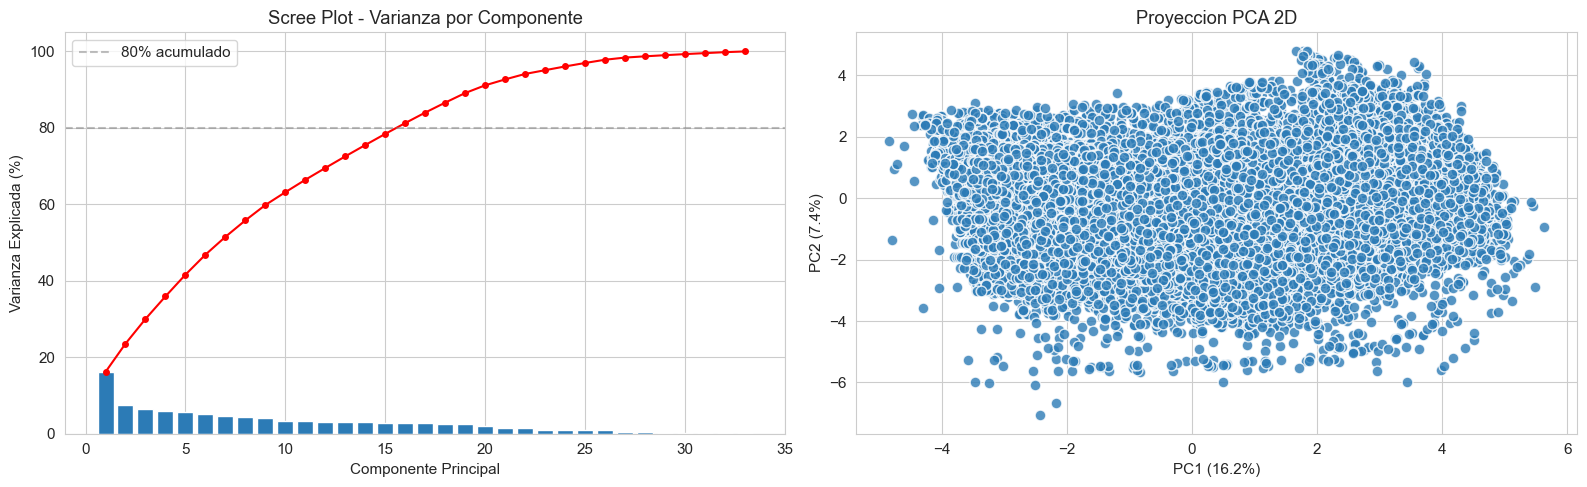

Componentes para explicar el 80% de la varianza: 16 de 33
Varianza explicada por PC1: 16.16%
Varianza explicada por PC1+PC2: 23.56%


In [17]:
# Calcular PCA con todos los componentes posibles
n_componentes = min(X_scaled.shape[0], X_scaled.shape[1])
pca = PCA(n_components=n_componentes, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada
varianza_acum = np.cumsum(pca.explained_variance_ratio_) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scree plot
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1),
            pca.explained_variance_ratio_ * 100, color="#2c7bb6", edgecolor="white")
axes[0].plot(range(1, len(varianza_acum) + 1), varianza_acum, "r-o", markersize=4)
axes[0].set_xlabel("Componente Principal")
axes[0].set_ylabel("Varianza Explicada (%)")
axes[0].set_title("Scree Plot - Varianza por Componente")
axes[0].axhline(y=80, color="gray", linestyle="--", alpha=0.5, label="80% acumulado")
axes[0].legend()

# Proyeccion 2D
scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c="#2c7bb6", s=60, edgecolor="white", alpha=0.8)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("Proyeccion PCA 2D")

plt.tight_layout()
plt.show()

# Componentes necesarios para 80% de varianza
n_80 = np.argmax(varianza_acum >= 80) + 1
print(f"Componentes para explicar el 80% de la varianza: {n_80} de {n_componentes}")
print(f"Varianza explicada por PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Varianza explicada por PC1+PC2: {varianza_acum[1]:.2f}%")


## Fase 4.1.1 : Analisis de Loadings PCA

Los loadings representan la correlacion entre cada variable original y cada
componente principal. Una variable con loadings altos (en valor absoluto) en los
primeros componentes es una variable que captura una proporcion significativa de
la varianza total del dataset.

Se calcula la "importancia PCA" de cada variable como la suma ponderada de sus
loadings absolutos por la varianza explicada de cada componente.


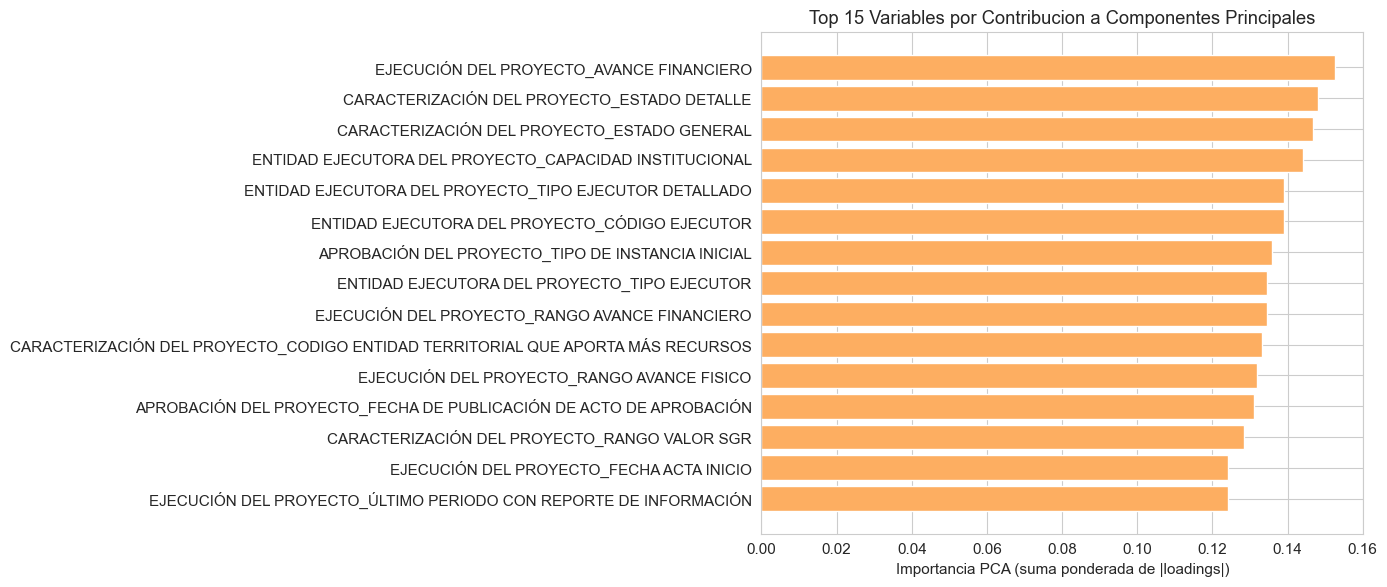

Top 15 variables por importancia PCA:
  EJECUCIÓN DEL PROYECTO_AVANCE FINANCIERO: 0.152566
  CARACTERIZACIÓN DEL PROYECTO_ESTADO DETALLE: 0.148040
  CARACTERIZACIÓN DEL PROYECTO_ESTADO GENERAL: 0.146658
  ENTIDAD EJECUTORA DEL PROYECTO_CAPACIDAD INSTITUCIONAL: 0.144078
  ENTIDAD EJECUTORA DEL PROYECTO_TIPO EJECUTOR DETALLADO: 0.139089
  ENTIDAD EJECUTORA DEL PROYECTO_CÓDIGO EJECUTOR: 0.138999
  APROBACIÓN DEL PROYECTO_TIPO DE INSTANCIA INICIAL: 0.135756
  ENTIDAD EJECUTORA DEL PROYECTO_TIPO EJECUTOR: 0.134601
  EJECUCIÓN DEL PROYECTO_RANGO AVANCE FINANCIERO: 0.134486
  CARACTERIZACIÓN DEL PROYECTO_CODIGO ENTIDAD TERRITORIAL QUE APORTA MÁS RECURSOS: 0.133342
  EJECUCIÓN DEL PROYECTO_RANGO AVANCE FISICO: 0.131866
  APROBACIÓN DEL PROYECTO_FECHA DE PUBLICACIÓN DE ACTO DE APROBACIÓN: 0.131211
  CARACTERIZACIÓN DEL PROYECTO_RANGO VALOR SGR: 0.128432
  EJECUCIÓN DEL PROYECTO_FECHA ACTA INICIO: 0.124253
  EJECUCIÓN DEL PROYECTO_ÚLTIMO PERIODO CON REPORTE DE INFORMACIÓN: 0.124121


In [18]:
# Matriz de loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(n_componentes)],
    index=X.columns
)

# Importancia PCA: suma ponderada de |loading| x varianza_explicada
importancia_pca = (loadings.abs() * pca.explained_variance_ratio_).sum(axis=1)
importancia_pca = importancia_pca.sort_values(ascending=False)

# Visualizacion de loadings PC1 vs PC2
fig, ax = plt.subplots(figsize=(14, max(6, min(TOP_N, len(importancia_pca)) * 0.4)))
top_pca = importancia_pca.head(TOP_N)
ax.barh(
    top_pca.index[::-1],
    top_pca.values[::-1],
    color="#fdae61", edgecolor="white"
)
ax.set_xlabel("Importancia PCA (suma ponderada de |loadings|)")
ax.set_title(f"Top {min(TOP_N, len(top_pca))} Variables por Contribucion a Componentes Principales")
plt.tight_layout()
plt.show()

print(f"Top {min(TOP_N, len(top_pca))} variables por importancia PCA:")
for var, val in top_pca.items():
    print(f"  {var}: {val:.6f}")


## Fase 4.2 : Clustering Jerarquico

El dendrograma permite visualizar la estructura de agrupamiento natural de los
proyectos sin asumir un numero predefinido de clusters. Se utiliza el metodo
de Ward, que minimiza la varianza intra-cluster, y la distancia euclidiana
sobre los datos estandarizados.


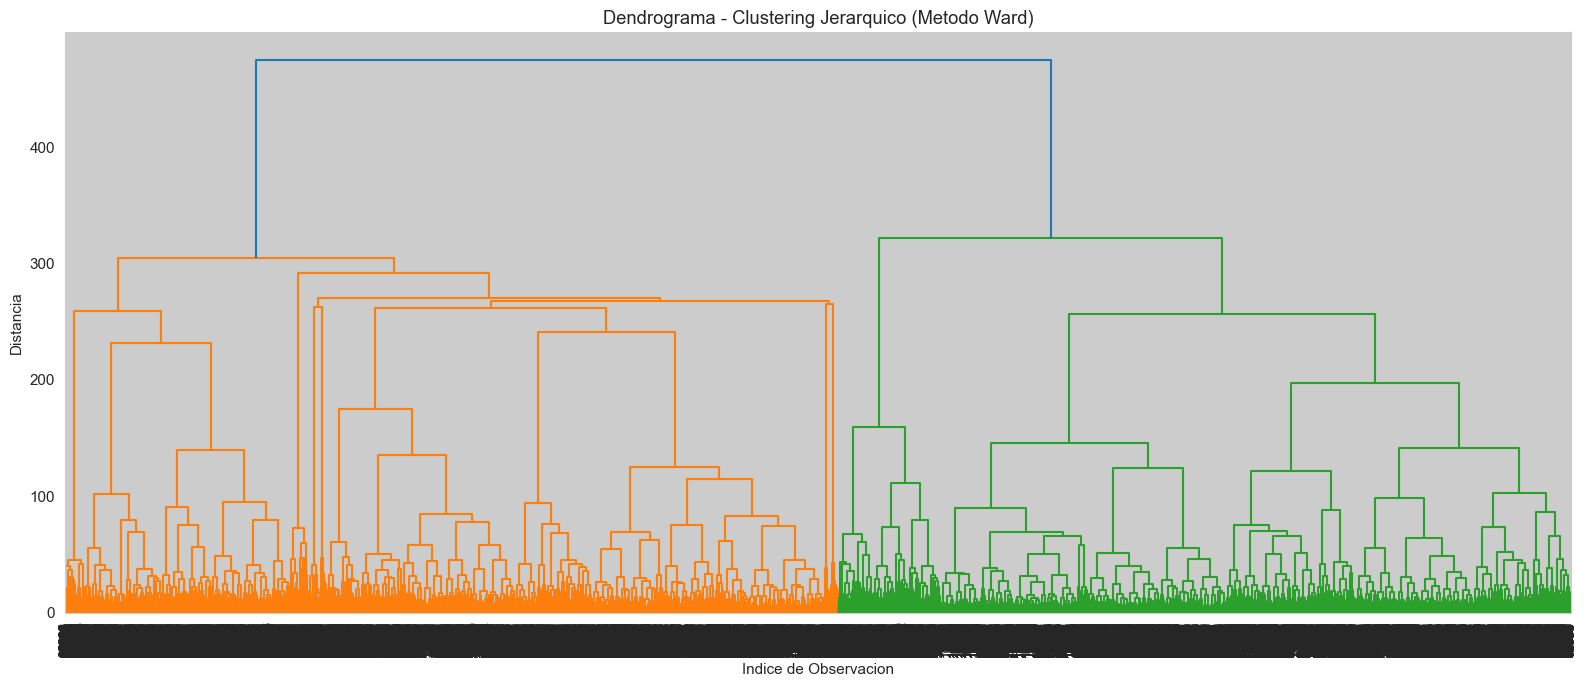

In [19]:
# Dendrograma
if X_scaled.shape[0] >= 3:
    Z = linkage(X_scaled, method="ward", metric="euclidean")

    fig, ax = plt.subplots(figsize=(16, 7))
    dendrogram(
        Z,
        leaf_rotation=90,
        leaf_font_size=9,
        color_threshold=0.7 * max(Z[:, 2]),
        ax=ax
    )
    ax.set_title("Dendrograma - Clustering Jerarquico (Metodo Ward)")
    ax.set_xlabel("Indice de Observacion")
    ax.set_ylabel("Distancia")
    plt.tight_layout()
    plt.show()
else:
    print("Se requieren al menos 3 observaciones para el dendrograma.")


## Fase 4.3 : K-Means con Analisis de Silueta

Se evaluan multiples valores de K para identificar el numero optimo de clusters
mediante el coeficiente de silueta (rango [-1, 1]; valores mas altos indican
clusters mejor definidos) y el metodo del codo (inercia).

El coeficiente de silueta mide que tan similar es cada observacion a su propio
cluster comparado con el cluster mas cercano.


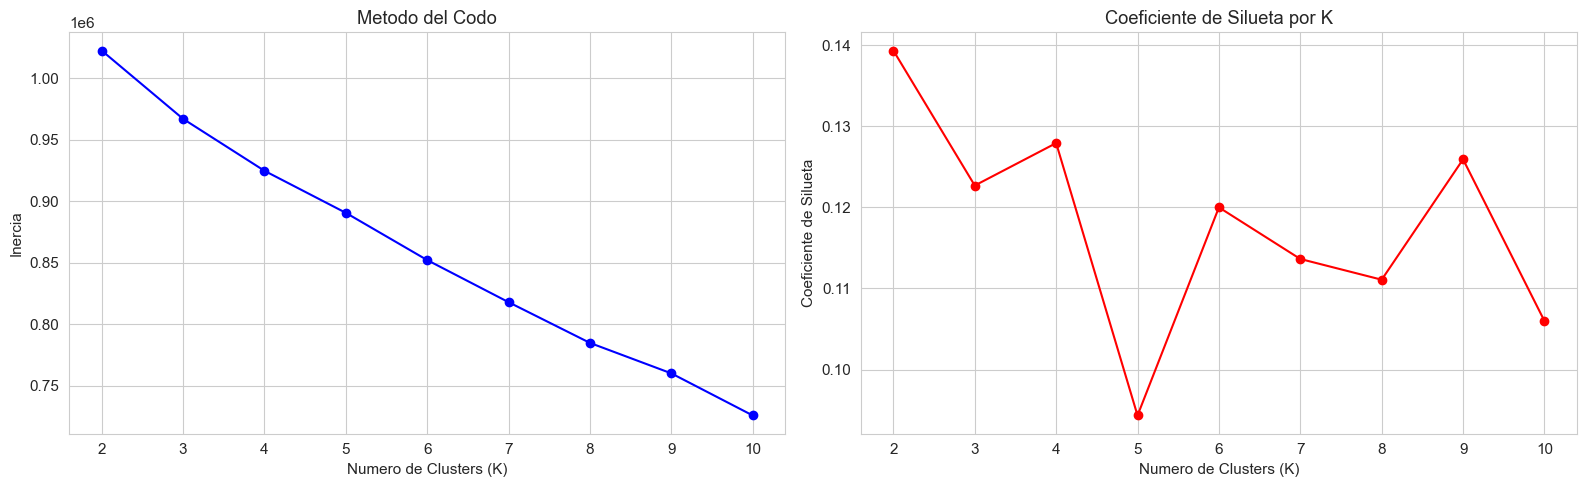

K optimo segun coeficiente de silueta: 2
Coeficiente de silueta para K=2: 0.1393

Distribucion de clusters (K=2):
cluster_kmeans
0    17058
1    18330
Name: count, dtype: int64


In [20]:
# Evaluar K de 2 a MAX_K_CLUSTERS (o n-1 si hay pocas observaciones)
max_k = min(MAX_K_CLUSTERS, X_scaled.shape[0] - 1)

if max_k >= 2:
    rango_k = range(2, max_k + 1)
    inercias = []
    siluetas = []

    for k in rango_k:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X_scaled)
        inercias.append(km.inertia_)
        sil = silhouette_score(X_scaled, labels) if len(set(labels)) > 1 else 0
        siluetas.append(sil)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Metodo del codo
    axes[0].plot(list(rango_k), inercias, "b-o", markersize=6)
    axes[0].set_xlabel("Numero de Clusters (K)")
    axes[0].set_ylabel("Inercia")
    axes[0].set_title("Metodo del Codo")

    # Silueta
    axes[1].plot(list(rango_k), siluetas, "r-o", markersize=6)
    axes[1].set_xlabel("Numero de Clusters (K)")
    axes[1].set_ylabel("Coeficiente de Silueta")
    axes[1].set_title("Coeficiente de Silueta por K")

    plt.tight_layout()
    plt.show()

    # K optimo por silueta
    k_optimo = list(rango_k)[np.argmax(siluetas)]
    print(f"K optimo segun coeficiente de silueta: {k_optimo}")
    print(f"Coeficiente de silueta para K={k_optimo}: {max(siluetas):.4f}")

    # Asignar clusters con K optimo
    km_final = KMeans(n_clusters=k_optimo, random_state=RANDOM_STATE, n_init=10)
    df_encoded["cluster_kmeans"] = km_final.fit_predict(X_scaled)

    print(f"\nDistribucion de clusters (K={k_optimo}):")
    print(df_encoded["cluster_kmeans"].value_counts().sort_index())
else:
    print(f"AVISO: Solo {X_scaled.shape[0]} observaciones. K-Means requiere al menos 3.")
    print("Se omite el analisis de K-Means.")


## Fase 4.3.1 : Visualizacion de Clusters en Espacio PCA


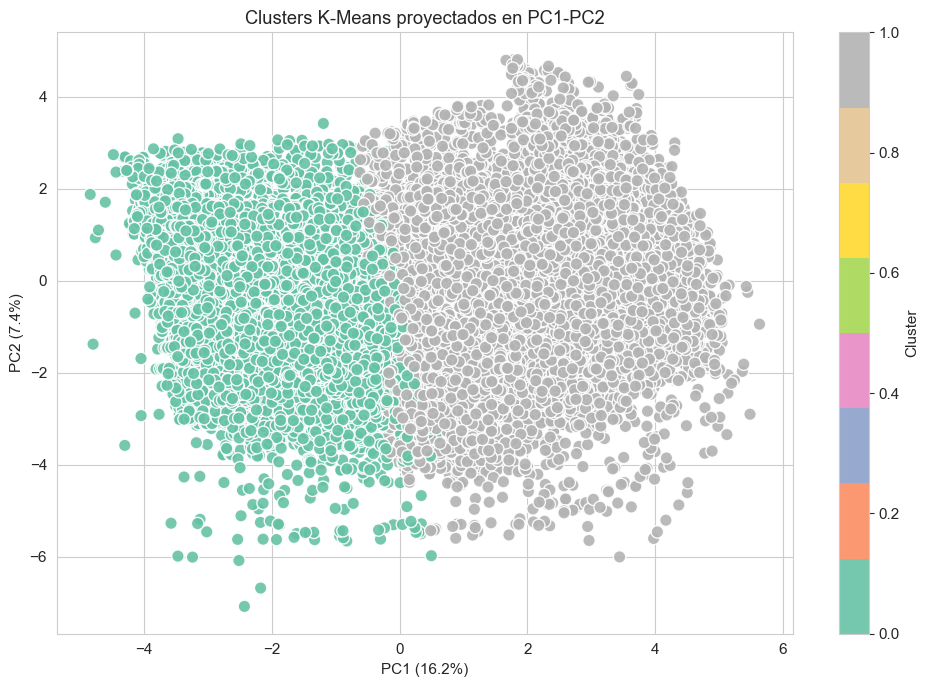

In [21]:
if "cluster_kmeans" in df_encoded.columns and X_pca.shape[1] >= 2:
    fig, ax = plt.subplots(figsize=(10, 7))
    scatter = ax.scatter(
        X_pca[:, 0], X_pca[:, 1],
        c=df_encoded["cluster_kmeans"],
        cmap="Set2",
        s=80,
        edgecolor="white",
        alpha=0.9
    )
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.set_title("Clusters K-Means proyectados en PC1-PC2")
    plt.colorbar(scatter, label="Cluster")
    plt.tight_layout()
    plt.show()


# Fase 5 : Seleccion de Variables Relevantes (No Supervisada)

Se utilizan tres metodos complementarios que no requieren una variable objetivo:

1. Varianza Normalizada: las variables con mayor varianza (tras estandarizar)
   son las que mas diferencian las observaciones entre si.

2. Importancia PCA (Loadings Ponderados): las variables que mas contribuyen a los
   primeros componentes principales capturan la mayor proporcion de la estructura
   latente del dataset.

3. Laplacian Score: mide la capacidad de cada variable para preservar la estructura
   local del grafo de vecinos mas cercanos. Un Laplacian Score bajo indica que la
   variable respeta la geometria local de los datos (los puntos cercanos tienden a
   tener valores similares), lo que la hace informativa para clustering y segmentacion.

Los tres metodos se consolidan en un ranking cruzado que promedia las posiciones
de cada variable. Las variables consistentemente bien rankeadas en los tres criterios
son las candidatas mas solidas para cualquier analisis posterior.


In [22]:
# =====================================================================
# METODO 1: Varianza Normalizada
# =====================================================================

# Usar MinMaxScaler para obtener varianza en rango [0,1]
mms = MinMaxScaler()
X_minmax = pd.DataFrame(
    mms.fit_transform(X),
    columns=X.columns
)
varianza_norm = X_minmax.var().sort_values(ascending=False)

print("METODO 1: Varianza Normalizada")
print(f"Top {min(TOP_N, len(varianza_norm))} variables:")
for var, val in varianza_norm.head(TOP_N).items():
    print(f"  {var}: {val:.6f}")


METODO 1: Varianza Normalizada
Top 15 variables:
  APROBACIÓN DEL PROYECTO_LEY DE APROBACIÓN: 0.248872
  EJECUCIÓN DEL PROYECTO_RANGO TOTAL PAGOS: 0.186613
  CARACTERIZACIÓN DEL PROYECTO_RANGO VALOR SGR: 0.181801
  CARACTERIZACIÓN DEL PROYECTO_SECTOR: 0.150706
  CARACTERIZACIÓN DEL PROYECTO_ESTADO GENERAL: 0.148651
  CARACTERIZACIÓN DEL PROYECTO_ESTADO DETALLE: 0.144057
  ENTIDAD EJECUTORA DEL PROYECTO_CAPACIDAD INSTITUCIONAL: 0.133137
  APROBACIÓN DEL PROYECTO_APROBACIONES POR GOBIERNO: 0.131655
  CARACTERIZACIÓN DEL PROYECTO_REGION ENTIDAD QUE MÁS APORTA RECURSOS: 0.130235
  EJECUCIÓN DEL PROYECTO_OFICINA REGIONAL: 0.115766
  ENTIDAD EJECUTORA DEL PROYECTO_DIGITO VERIFICACIÓN: 0.103976
  EJECUCIÓN DEL PROYECTO_ÚLTIMO PERIODO CON REPORTE DE INFORMACIÓN: 0.097081
  ENTIDAD EJECUTORA DEL PROYECTO_CÓDIGO EJECUTOR: 0.086080
  ENTIDAD EJECUTORA DEL PROYECTO_DEPARTAMENTO EJECUTOR: 0.080488
  CARACTERIZACIÓN DEL PROYECTO_DEPARTAMENTO ENTIDAD QUE MÁS APORTA RECURSOS: 0.079930


In [23]:
# =====================================================================
# METODO 2: Importancia PCA (ya calculada en Fase 4.1.1)
# =====================================================================
print("METODO 2: Importancia PCA (Loadings Ponderados)")
print(f"Top {min(TOP_N, len(importancia_pca))} variables:")
for var, val in importancia_pca.head(TOP_N).items():
    print(f"  {var}: {val:.6f}")


METODO 2: Importancia PCA (Loadings Ponderados)
Top 15 variables:
  EJECUCIÓN DEL PROYECTO_AVANCE FINANCIERO: 0.152566
  CARACTERIZACIÓN DEL PROYECTO_ESTADO DETALLE: 0.148040
  CARACTERIZACIÓN DEL PROYECTO_ESTADO GENERAL: 0.146658
  ENTIDAD EJECUTORA DEL PROYECTO_CAPACIDAD INSTITUCIONAL: 0.144078
  ENTIDAD EJECUTORA DEL PROYECTO_TIPO EJECUTOR DETALLADO: 0.139089
  ENTIDAD EJECUTORA DEL PROYECTO_CÓDIGO EJECUTOR: 0.138999
  APROBACIÓN DEL PROYECTO_TIPO DE INSTANCIA INICIAL: 0.135756
  ENTIDAD EJECUTORA DEL PROYECTO_TIPO EJECUTOR: 0.134601
  EJECUCIÓN DEL PROYECTO_RANGO AVANCE FINANCIERO: 0.134486
  CARACTERIZACIÓN DEL PROYECTO_CODIGO ENTIDAD TERRITORIAL QUE APORTA MÁS RECURSOS: 0.133342
  EJECUCIÓN DEL PROYECTO_RANGO AVANCE FISICO: 0.131866
  APROBACIÓN DEL PROYECTO_FECHA DE PUBLICACIÓN DE ACTO DE APROBACIÓN: 0.131211
  CARACTERIZACIÓN DEL PROYECTO_RANGO VALOR SGR: 0.128432
  EJECUCIÓN DEL PROYECTO_FECHA ACTA INICIO: 0.124253
  EJECUCIÓN DEL PROYECTO_ÚLTIMO PERIODO CON REPORTE DE INFORMA

In [24]:
# =====================================================================
# METODO 3: Laplacian Score
# =====================================================================

def calcular_laplacian_score(X, n_vecinos=5):
    """
    Calcula el Laplacian Score para cada variable.

    El Laplacian Score mide la suavidad de cada feature respecto al grafo
    de k-vecinos mas cercanos. Un score bajo indica que la variable
    preserva bien la estructura local (es informativa).

    Parametros
    ----------
    X : pd.DataFrame o np.array
        Datos estandarizados.
    n_vecinos : int
        Numero de vecinos para construir el grafo.

    Retorna
    -------
    pd.Series
        Laplacian Score por variable (menor = mas relevante).
    """
    X_arr = X.values if isinstance(X, pd.DataFrame) else X
    n_samples, n_features = X_arr.shape

    # Construir grafo de k-vecinos (simetrico)
    n_neighbors_actual = min(n_vecinos, n_samples - 1)
    W = kneighbors_graph(X_arr, n_neighbors=n_neighbors_actual, mode="connectivity")
    W = 0.5 * (W + W.T)  # Simetrizar

    # Matriz de grado y Laplaciana
    D = np.array(W.sum(axis=1)).flatten()
    L = np.diag(D) - W.toarray()

    scores = np.zeros(n_features)
    ones = np.ones(n_samples)

    for j in range(n_features):
        f = X_arr[:, j]
        # Centrar respecto al grafo: f_tilde = f - (f^T D 1 / 1^T D 1) * 1
        f_tilde = f - (f @ D * ones.sum()) / (D.sum()) * ones
        # Laplacian Score = f_tilde^T L f_tilde / f_tilde^T D f_tilde
        numerador = f_tilde @ L @ f_tilde
        denominador = f_tilde @ (D * f_tilde)

        if denominador < 1e-10:
            scores[j] = np.inf  # Variable constante respecto al grafo
        else:
            scores[j] = numerador / denominador

    if isinstance(X, pd.DataFrame):
        return pd.Series(scores, index=X.columns)
    return scores


# Calcular Laplacian Score
n_vec = min(N_VECINOS_LAPLACIAN, X_scaled.shape[0] - 1)
lap_scores = calcular_laplacian_score(X_scaled, n_vecinos=n_vec)

# Menor score = mas relevante, invertir para ranking
# (usaremos 1/score para que mayor = mejor, consistente con los otros metodos)
lap_scores_inv = 1 / (lap_scores + 1e-10)
lap_scores_inv = lap_scores_inv.sort_values(ascending=False)

print("METODO 3: Laplacian Score (invertido: mayor = mas relevante)")
print(f"Top {min(TOP_N, len(lap_scores_inv))} variables:")
for var, val in lap_scores_inv.head(TOP_N).items():
    print(f"  {var}: {val:.6f}")


METODO 3: Laplacian Score (invertido: mayor = mas relevante)
Top 15 variables:
  CARACTERIZACIÓN DEL PROYECTO_PROYECTO TIPO: 9999998337.826347
  OTRAS VARIABLES DEL PROYECTO_PROYECTOS OBRAS DE INF. FÍSICA EN IPES: 9999996625.042881
  EJECUCIÓN DEL PROYECTO_AVANCE FINANCIERO: 6684164.419071
  EJECUCIÓN DEL PROYECTO_RANGO AVANCE FINANCIERO: 3534064.052305
  EJECUCIÓN DEL PROYECTO_ÚLTIMO PERIODO CON REPORTE DE INFORMACIÓN: 2413409.496838
  APROBACIÓN DEL PROYECTO_APROBACIONES POR GOBIERNO: 1678166.234449
  APROBACIÓN DEL PROYECTO_FECHA DE PUBLICACIÓN DE ACTO DE APROBACIÓN: 1523978.479403
  CARACTERIZACIÓN DEL PROYECTO_SECTOR: 1282511.602363
  CARACTERIZACIÓN DEL PROYECTO_REGION ENTIDAD QUE MÁS APORTA RECURSOS: 1059564.682214
  CARACTERIZACIÓN DEL PROYECTO_FECHA ESTADO DETALLE PROYECTO: 1046644.907159
  APROBACIÓN DEL PROYECTO_TIPO DE INSTANCIA INICIAL: 907741.579075
  APROBACIÓN DEL PROYECTO_LEY DE APROBACIÓN: 896095.084061
  EJECUCIÓN DEL PROYECTO_FECHA ACTA INICIO: 839791.184008
  CARAC

# Fase 6 : Consolidacion y Ranking Cruzado de Variables Relevantes

Se construye un DataFrame resumen que cruza los rankings de los tres metodos:
Varianza Normalizada, Importancia PCA y Laplacian Score. Cada variable recibe un
ranking por metodo (1 = mas relevante) y un score compuesto que es el promedio de
los tres rankings. Las variables que aparecen consistentemente en posiciones altas
en los tres metodos son las mas informativas para describir la estructura de los datos.


In [25]:
# =====================================================================
# CONSTRUCCION DEL RANKING CRUZADO
# =====================================================================

# DataFrame base con todas las variables
all_vars = X.columns.tolist()

# Ranking Varianza (1 = mayor varianza)
rank_var = varianza_norm.rank(ascending=False).astype(int)

# Ranking PCA (1 = mayor importancia)
rank_pca = importancia_pca.rank(ascending=False).astype(int)

# Ranking Laplacian (1 = mayor score invertido = menor Laplacian Score)
rank_lap = lap_scores_inv.rank(ascending=False).astype(int)

# Consolidar
resumen = pd.DataFrame({
    "Variable": all_vars,
    "Varianza_Norm": [varianza_norm.get(v, 0) for v in all_vars],
    "Rank_Varianza": [rank_var.get(v, len(all_vars)) for v in all_vars],
    "Importancia_PCA": [importancia_pca.get(v, 0) for v in all_vars],
    "Rank_PCA": [rank_pca.get(v, len(all_vars)) for v in all_vars],
    "Laplacian_Inv": [lap_scores_inv.get(v, 0) for v in all_vars],
    "Rank_Laplacian": [rank_lap.get(v, len(all_vars)) for v in all_vars],
})

# Score compuesto: promedio de rankings (menor = mejor)
resumen["Score_Compuesto"] = resumen[["Rank_Varianza", "Rank_PCA", "Rank_Laplacian"]].mean(axis=1)
resumen = resumen.sort_values("Score_Compuesto").reset_index(drop=True)

print("=" * 90)
print(f"TOP {min(TOP_N, len(resumen))} VARIABLES MAS RELEVANTES - RANKING CRUZADO NO SUPERVISADO")
print("=" * 90)
print(resumen.head(TOP_N)[[
    "Variable", "Rank_Varianza", "Rank_PCA", "Rank_Laplacian", "Score_Compuesto"
]].to_string(index=False))


TOP 15 VARIABLES MAS RELEVANTES - RANKING CRUZADO NO SUPERVISADO
                                                           Variable  Rank_Varianza  Rank_PCA  Rank_Laplacian  Score_Compuesto
                        CARACTERIZACIÓN DEL PROYECTO_ESTADO GENERAL              5         3              16         8.000000
                           EJECUCIÓN DEL PROYECTO_AVANCE FINANCIERO             24         1               3         9.333333
   EJECUCIÓN DEL PROYECTO_ÚLTIMO PERIODO CON REPORTE DE INFORMACIÓN             12        15               5        10.666667
                        CARACTERIZACIÓN DEL PROYECTO_ESTADO DETALLE              6         2              24        10.666667
                                CARACTERIZACIÓN DEL PROYECTO_SECTOR              4        21               8        11.000000
                  APROBACIÓN DEL PROYECTO_APROBACIONES POR GOBIERNO              8        19               6        11.000000
                          APROBACIÓN DEL PROYECTO_LEY

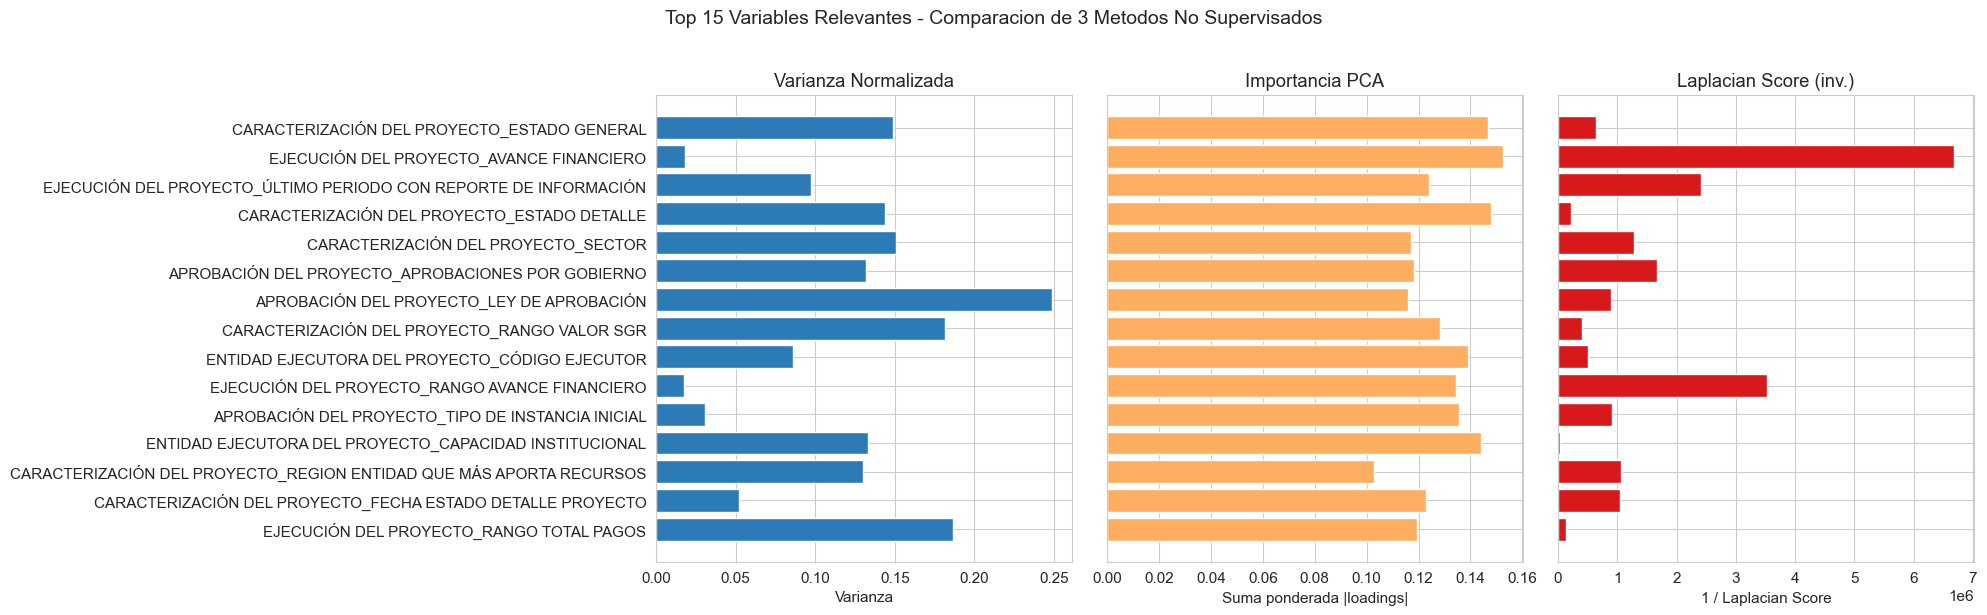

In [26]:
# =====================================================================
# VISUALIZACION COMPARATIVA
# =====================================================================

top_resumen = resumen.head(min(TOP_N, len(resumen))).copy()

fig, axes = plt.subplots(1, 3, figsize=(20, max(6, len(top_resumen) * 0.4)), sharey=True)

# Panel 1: Varianza Normalizada
axes[0].barh(
    top_resumen["Variable"][::-1],
    top_resumen["Varianza_Norm"][::-1],
    color="#2c7bb6", edgecolor="white"
)
axes[0].set_title("Varianza Normalizada")
axes[0].set_xlabel("Varianza")

# Panel 2: Importancia PCA
axes[1].barh(
    top_resumen["Variable"][::-1],
    top_resumen["Importancia_PCA"][::-1],
    color="#fdae61", edgecolor="white"
)
axes[1].set_title("Importancia PCA")
axes[1].set_xlabel("Suma ponderada |loadings|")

# Panel 3: Laplacian Score (invertido)
axes[2].barh(
    top_resumen["Variable"][::-1],
    top_resumen["Laplacian_Inv"][::-1],
    color="#d7191c", edgecolor="white"
)
axes[2].set_title("Laplacian Score (inv.)")
axes[2].set_xlabel("1 / Laplacian Score")

plt.suptitle(
    f"Top {len(top_resumen)} Variables Relevantes - Comparacion de 3 Metodos No Supervisados",
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()


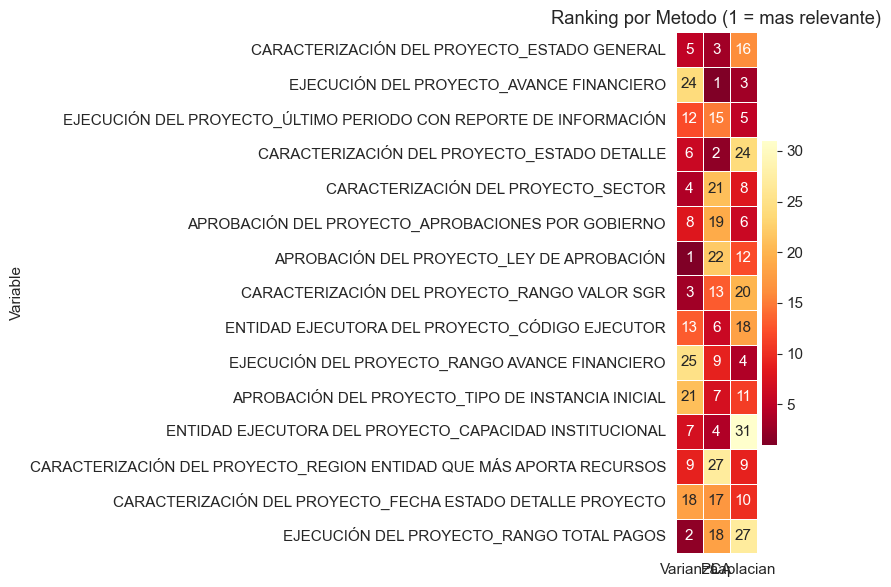

In [27]:
# =====================================================================
# HEATMAP DEL RANKING CRUZADO
# =====================================================================

top_para_heat = resumen.head(min(TOP_N, len(resumen))).set_index("Variable")
rank_cols = ["Rank_Varianza", "Rank_PCA", "Rank_Laplacian"]

fig, ax = plt.subplots(figsize=(8, max(5, len(top_para_heat) * 0.4)))
sns.heatmap(
    top_para_heat[rank_cols],
    annot=True,
    fmt=".0f",
    cmap="YlOrRd_r",  # Invertido: ranking bajo (bueno) = color claro
    linewidths=0.5,
    ax=ax
)
ax.set_title("Ranking por Metodo (1 = mas relevante)")
ax.set_xticklabels(["Varianza", "PCA", "Laplacian"], rotation=0)
plt.tight_layout()
plt.show()


In [28]:
# =====================================================================
# EXPORTAR RESUMEN A CSV
# =====================================================================

ruta_salida = "ranking_variables_no_supervisado.csv"
resumen.to_csv(ruta_salida, index=False, encoding="utf-8-sig")
print(f"Resumen exportado a: {ruta_salida}")
print(f"\nTotal variables analizadas: {len(resumen)}")
print(f"Variables en el Top {min(TOP_N, len(resumen))}: {len(top_resumen)}")


Resumen exportado a: ranking_variables_no_supervisado.csv

Total variables analizadas: 33
Variables en el Top 15: 15


## Fase 6.1 : Perfil de Clusters por Variables Top

Utilizando las variables mejor rankeadas y los clusters asignados por K-Means,
se genera un perfil descriptivo que muestra los valores promedio de cada variable
top dentro de cada cluster. Esto permite interpretar que caracteriza a cada grupo
de proyectos.


Perfil de Clusters (media por variable top):
cluster_kmeans                                                               0             1
CARACTERIZACIÓN DEL PROYECTO_ESTADO GENERAL                       2.924200e+00  1.939716e+00
EJECUCIÓN DEL PROYECTO_AVANCE FINANCIERO                          9.657872e+01  7.517596e+01
EJECUCIÓN DEL PROYECTO_ÚLTIMO PERIODO CON REPORTE DE INFORMACIÓN  1.595514e+06  1.746805e+06
CARACTERIZACIÓN DEL PROYECTO_ESTADO DETALLE                       7.867276e-01  2.496508e+00
CARACTERIZACIÓN DEL PROYECTO_SECTOR                               1.437232e+01  1.292510e+01
APROBACIÓN DEL PROYECTO_APROBACIONES POR GOBIERNO                 9.147028e-01  2.680251e+00
APROBACIÓN DEL PROYECTO_LEY DE APROBACIÓN                         4.162270e-03  8.963993e-01
CARACTERIZACIÓN DEL PROYECTO_RANGO VALOR SGR                      3.390960e+00  2.562302e+00
ENTIDAD EJECUTORA DEL PROYECTO_CÓDIGO EJECUTOR                    4.163080e+05  2.893956e+06
EJECUCIÓN DEL PROYECTO_RA

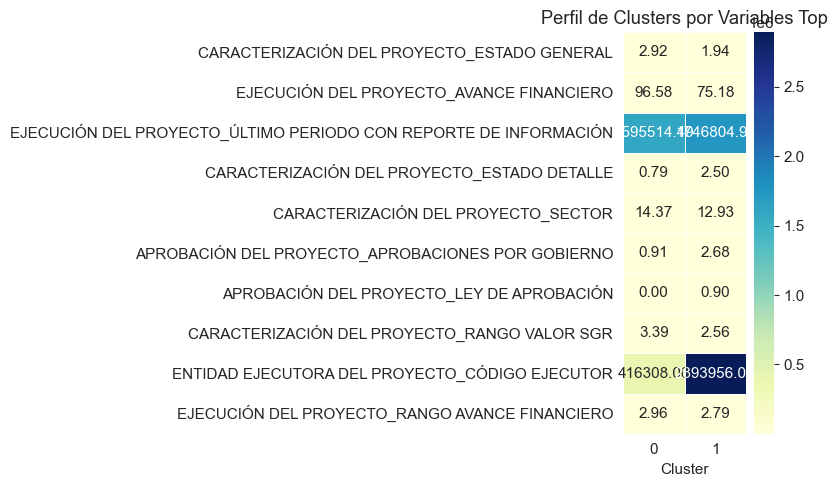

In [29]:
if "cluster_kmeans" in df_encoded.columns:
    # Seleccionar top variables del ranking
    top_vars_perfil = resumen.head(min(10, len(resumen)))["Variable"].tolist()
    top_vars_disponibles = [v for v in top_vars_perfil if v in df_encoded.columns]

    if top_vars_disponibles:
        perfil = df_encoded.groupby("cluster_kmeans")[top_vars_disponibles].mean()

        print("Perfil de Clusters (media por variable top):")
        print(perfil.T.to_string())

        # Heatmap del perfil
        fig, ax = plt.subplots(figsize=(max(8, perfil.shape[0] * 2), max(5, len(top_vars_disponibles) * 0.5)))
        sns.heatmap(
            perfil.T,
            annot=True,
            fmt=".2f",
            cmap="YlGnBu",
            linewidths=0.5,
            ax=ax
        )
        ax.set_title("Perfil de Clusters por Variables Top")
        ax.set_xlabel("Cluster")
        plt.tight_layout()
        plt.show()
else:
    print("No se ejecuto K-Means. Omitiendo perfil de clusters.")


# Resumen Ejecutivo del Pipeline

## Etapas completadas

1. Ingesta: lectura del archivo Excel con headers multinivel y aplanamiento
   automatico de nombres de columna preservando la jerarquia de grupos.
2. Limpieza: eliminacion de columnas con mas del 40% de nulos (configurable),
   imputacion por mediana/moda, y remocion de variables con varianza cercana a cero.
3. Correlacion y VIF: deteccion de pares altamente correlacionados y eliminacion
   iterativa de variables con multicolinealidad severa.
4. Analisis exploratorio: PCA para visualizacion de estructura latente, clustering
   jerarquico para detectar agrupamientos naturales, y K-Means con seleccion
   automatica de K por coeficiente de silueta.
5. Feature Selection no supervisada: ranking cruzado de tres metodos (Varianza
   Normalizada, Loadings PCA ponderados y Laplacian Score) que identifican las
   variables mas informativas sin necesidad de una variable objetivo.

## Interpretacion del Ranking

Las variables con un Score Compuesto bajo (cercano a 1) aparecen consistentemente
en las primeras posiciones de los tres metodos, lo que indica que:
- tienen alta dispersion (varianza),
- capturan la mayor proporcion de la estructura del dataset (PCA), y
- preservan bien la geometria local de los datos (Laplacian).

Estas son las variables que mas diferencian los proyectos entre si y que mayor
poder descriptivo tienen para segmentacion y analisis posterior.

## Notas para el usuario

- El archivo ranking_variables_no_supervisado.csv contiene el resumen completo.
- Los umbrales UMBRAL_NULOS, UMBRAL_VARIANZA, UMBRAL_VIF y N_VECINOS_LAPLACIAN
  son configurables en la seccion de variables globales.
- Para el dataset completo (~35,000 filas), todos los metodos funcionaran con
  mayor estabilidad estadistica. Con la muestra actual de 11 filas, los resultados
  son indicativos pero no concluyentes.
- Si en el futuro se define una variable objetivo, el notebook original con
  Random Forest, SHAP y LASSO sigue disponible.
